In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import RobustScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

/home/bulent/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:34: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # fraction of entries where abs(y_true - y_pred) < epsilon
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [3]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -166.4442895672524 whereas concordance corr coef is 0.01180328947707736


In [4]:
with open('stations-6to31.pkl', 'rb') as f:
    datas = pickle.load(f)
    
x_train6_ = datas['x_train6']
y_train6 = datas['y_train6']
x_train_ = datas['x_train']
y_train = datas['y_train']
x_dev_ = datas['x_dev']
y_dev = datas['y_dev']
x_test_ = datas['x_test']
y_test = datas['y_test']

print(f'x_train shape: {x_train_.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [5]:
def scale_data(scaler, datas):
    # scaler is a scaling function from sklearn library
    # datas is a dictionary, containing 3 sets of x_data with keys - x_train, x_dev, x_test
    # fit on x_train and return the transformed sets of data
    
    x_train = scaler.fit_transform(datas['x_train'].astype(float))
    x_dev = scaler.transform(datas['x_dev'].astype(float))
    x_test = scaler.transform(datas['x_test'].astype(float))
    
    transformed = {'x_train': x_train, 'x_dev': x_dev, 'x_test': x_test}
    return transformed

data6_ = {'x_train': x_train6_, 'x_dev': x_dev_, 'x_test': x_test_}
data_ = {'x_train': x_train_, 'x_dev': x_dev_, 'x_test': x_test_}

data6 = scale_data(RobustScaler(), data6_)
data = scale_data(RobustScaler(), data_)

x_train6 = data6['x_train']
x_train = data['x_train']

x_dev6 = data6['x_dev']
x_dev = data['x_dev']

x_test6 = data6['x_test']
x_test = data['x_test']

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [6]:
data6_3v_ = {'x_train': x_train6_[:, [1, 3, 2, 0]], 'x_dev': x_dev_[:, [1, 3, 2, 0]], 'x_test': x_test_[:, [1, 3, 2, 0]]}
data_3v_ = {'x_train': x_train_[:, [1, 3, 2, 0]], 'x_dev': x_dev_[:, [1, 3, 2, 0]], 'x_test': x_test_[:, [1, 3, 2, 0]]}

data6_3v = scale_data(RobustScaler(), data6_3v_)
data_3v = scale_data(RobustScaler(), data_3v_)

x_train6_3v = data6_3v['x_train']
x_train_3v = data_3v['x_train']

x_dev6_3v = data6_3v['x_dev']
x_dev_3v = data_3v['x_dev']

x_test6_3v = data6_3v['x_test']
x_test_3v = data_3v['x_test']

y_train6_hh0 = y_train6 / x_train6_[:, 4]
y_train_hh0 = y_train / x_train_[:, 4]
y_dev_hh0 = y_dev / x_dev_[:, 4]
y_test_hh0 = y_test / x_test_[:, 4]

print(f'x_train shape: {x_train_3v.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_3v.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_3v.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_3v.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 4), y_train shape: (52416,)
x_train6 shape: (10654, 4), y_train6 shape: (10654,)
x_dev shape: (9011, 4), y_dev shape: (9011,)
x_test shape: (16899, 4), y_test shape: (16899,)


In [7]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test6 = []
metrics_train6 = []
metrics_dev6 = []
print('Evaluating metrics for 6station trained NN \n')
for i in range(50):
    modelname = './6to31stats-4vars-hh0/6stations-hh0-nNTPhi {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_test_[:, 4])
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_dev_[:, 4])
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_train6_[:, 4])
    mse = MSE( y_train6, p )
    rmse = sqrt( mse )
    mae = MAE( y_train6, p )
    r2 = R2( y_train6, p )
    evs = EVS( y_train6, p )
    fie_h = FIE( y_train6, p, 0.5)
    fie_o = FIE( y_train6, p, 1)
    fie_oh = FIE( y_train6, p, 1.5)
    lin = concorr(y_train6, p)

    metrics_train6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 6station trained NN 

C01 » RMSE: 4.2007, MAE: 2.1079, R2: 0.7598, EVS: 0.7638, FIE_H: 0.2440, FIE_O: 0.4533, FIE_OH: 0.6162, LINCC: 0.8802
C01 » RMSE: 2.4543, MAE: 1.6837, R2: 0.9108, EVS: 0.9122, FIE_H: 0.2190, FIE_O: 0.4250, FIE_OH: 0.5969, LINCC: 0.9563
C01 » RMSE: 3.8980, MAE: 1.9383, R2: 0.8223, EVS: 0.8236, FIE_H: 0.2693, FIE_O: 0.4888, FIE_OH: 0.6437, LINCC: 0.9060
C02 » RMSE: 4.0712, MAE: 2.3170, R2: 0.7744, EVS: 0.7844, FIE_H: 0.2097, FIE_O: 0.3890, FIE_OH: 0.5307, LINCC: 0.8752
C02 » RMSE: 2.5984, MAE: 1.8857, R2: 0.9000, EVS: 0.9056, FIE_H: 0.1862, FIE_O: 0.3690, FIE_OH: 0.5231, LINCC: 0.9466
C02 » RMSE: 3.8921, MAE: 2.2583, R2: 0.8228, EVS: 0.8228, FIE_H: 0.2089, FIE_O: 0.3822, FIE_OH: 0.5224, LINCC: 0.8961
C03 » RMSE: 4.1092, MAE: 2.0940, R2: 0.7702, EVS: 0.7749, FIE_H: 0.2350, FIE_O: 0.4450, FIE_OH: 0.6165, LINCC: 0.8842
C03 » RMSE: 2.4403, MAE: 1.7152, R2: 0.9118, EVS: 0.9133, FIE_H: 0.2060, FIE_O: 0.4025, FIE_OH: 0.5771, LINCC: 0.9565
C03 » RMSE:

C24 » RMSE: 3.9089, MAE: 1.8759, R2: 0.8213, EVS: 0.8274, FIE_H: 0.3069, FIE_O: 0.5236, FIE_OH: 0.6678, LINCC: 0.9020
C25 » RMSE: 4.1354, MAE: 2.1702, R2: 0.7672, EVS: 0.7688, FIE_H: 0.2132, FIE_O: 0.4148, FIE_OH: 0.5780, LINCC: 0.8835
C25 » RMSE: 2.4760, MAE: 1.7658, R2: 0.9092, EVS: 0.9093, FIE_H: 0.1925, FIE_O: 0.3739, FIE_OH: 0.5544, LINCC: 0.9557
C25 » RMSE: 3.8921, MAE: 1.8533, R2: 0.8228, EVS: 0.8259, FIE_H: 0.2953, FIE_O: 0.5261, FIE_OH: 0.6807, LINCC: 0.9055
C26 » RMSE: 4.1235, MAE: 2.0397, R2: 0.7686, EVS: 0.7716, FIE_H: 0.2607, FIE_O: 0.4793, FIE_OH: 0.6412, LINCC: 0.8826
C26 » RMSE: 2.3711, MAE: 1.6415, R2: 0.9167, EVS: 0.9171, FIE_H: 0.2224, FIE_O: 0.4219, FIE_OH: 0.6029, LINCC: 0.9585
C26 » RMSE: 3.8972, MAE: 1.8830, R2: 0.8224, EVS: 0.8256, FIE_H: 0.2832, FIE_O: 0.5126, FIE_OH: 0.6670, LINCC: 0.9045
C27 » RMSE: 4.0208, MAE: 2.1401, R2: 0.7799, EVS: 0.7862, FIE_H: 0.2281, FIE_O: 0.4325, FIE_OH: 0.5834, LINCC: 0.8845
C27 » RMSE: 2.5223, MAE: 1.7578, R2: 0.9058, EVS: 0.9091

C48 » RMSE: 4.0027, MAE: 2.0846, R2: 0.7819, EVS: 0.7838, FIE_H: 0.2320, FIE_O: 0.4346, FIE_OH: 0.6012, LINCC: 0.8888
C48 » RMSE: 2.4179, MAE: 1.7044, R2: 0.9134, EVS: 0.9135, FIE_H: 0.2066, FIE_O: 0.4017, FIE_OH: 0.5801, LINCC: 0.9573
C48 » RMSE: 3.8786, MAE: 1.9020, R2: 0.8240, EVS: 0.8263, FIE_H: 0.2590, FIE_O: 0.4954, FIE_OH: 0.6584, LINCC: 0.9046
C49 » RMSE: 4.1995, MAE: 2.2486, R2: 0.7600, EVS: 0.7707, FIE_H: 0.2168, FIE_O: 0.3981, FIE_OH: 0.5475, LINCC: 0.8746
C49 » RMSE: 2.5877, MAE: 1.8423, R2: 0.9008, EVS: 0.9066, FIE_H: 0.1943, FIE_O: 0.3663, FIE_OH: 0.5312, LINCC: 0.9490
C49 » RMSE: 3.8267, MAE: 2.0303, R2: 0.8287, EVS: 0.8287, FIE_H: 0.2264, FIE_O: 0.4315, FIE_OH: 0.5989, LINCC: 0.9042
C50 » RMSE: 4.2603, MAE: 2.1723, R2: 0.7530, EVS: 0.7632, FIE_H: 0.2300, FIE_O: 0.4317, FIE_OH: 0.5971, LINCC: 0.8751
C50 » RMSE: 2.5390, MAE: 1.7573, R2: 0.9045, EVS: 0.9091, FIE_H: 0.2073, FIE_O: 0.4003, FIE_OH: 0.5671, LINCC: 0.9526
C50 » RMSE: 3.8151, MAE: 1.8918, R2: 0.8298, EVS: 0.8299

In [8]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test31 = []
metrics_train31 = []
metrics_dev31 = []
print('Evaluating metrics for 31station trained NN \n')
for i in range(50):
    modelname = './6to31stats-4vars-hh0/31stations-hh0-nNTPhi {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_test_[:, 4])
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_dev_[:, 4])
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_train_[:, 4])
    mse = MSE( y_train, p )
    rmse = sqrt( mse )
    mae = MAE( y_train, p )
    r2 = R2( y_train, p )
    evs = EVS( y_train, p )
    fie_h = FIE( y_train, p, 0.5)
    fie_o = FIE( y_train, p, 1)
    fie_oh = FIE( y_train, p, 1.5)
    lin = concorr(y_train, p)

    metrics_train31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 31station trained NN 

C01 » RMSE: 4.1772, MAE: 1.9832, R2: 0.7625, EVS: 0.7708, FIE_H: 0.2866, FIE_O: 0.5168, FIE_OH: 0.6766, LINCC: 0.8818
C01 » RMSE: 2.1952, MAE: 1.3589, R2: 0.9286, EVS: 0.9296, FIE_H: 0.3137, FIE_O: 0.5671, FIE_OH: 0.7170, LINCC: 0.9652
C01 » RMSE: 3.0311, MAE: 1.5817, R2: 0.8766, EVS: 0.8781, FIE_H: 0.2996, FIE_O: 0.5393, FIE_OH: 0.6976, LINCC: 0.9376
C02 » RMSE: 4.3218, MAE: 2.0615, R2: 0.7458, EVS: 0.7590, FIE_H: 0.2746, FIE_O: 0.4984, FIE_OH: 0.6515, LINCC: 0.8697
C02 » RMSE: 2.2242, MAE: 1.3514, R2: 0.9267, EVS: 0.9302, FIE_H: 0.3206, FIE_O: 0.5763, FIE_OH: 0.7278, LINCC: 0.9628
C02 » RMSE: 2.9876, MAE: 1.5738, R2: 0.8801, EVS: 0.8805, FIE_H: 0.2920, FIE_O: 0.5319, FIE_OH: 0.6971, LINCC: 0.9372
C03 » RMSE: 3.9623, MAE: 1.9147, R2: 0.7863, EVS: 0.7909, FIE_H: 0.2930, FIE_O: 0.5298, FIE_OH: 0.6899, LINCC: 0.8924
C03 » RMSE: 2.2662, MAE: 1.4145, R2: 0.9239, EVS: 0.9246, FIE_H: 0.3013, FIE_O: 0.5450, FIE_OH: 0.7001, LINCC: 0.9626
C03 » RMSE

C24 » RMSE: 2.2065, MAE: 1.3647, R2: 0.9279, EVS: 0.9293, FIE_H: 0.3103, FIE_O: 0.5602, FIE_OH: 0.7139, LINCC: 0.9643
C24 » RMSE: 3.0046, MAE: 1.5539, R2: 0.8788, EVS: 0.8803, FIE_H: 0.3103, FIE_O: 0.5466, FIE_OH: 0.7031, LINCC: 0.9378
C25 » RMSE: 3.9290, MAE: 1.8894, R2: 0.7899, EVS: 0.7936, FIE_H: 0.3012, FIE_O: 0.5415, FIE_OH: 0.6931, LINCC: 0.8942
C25 » RMSE: 2.1888, MAE: 1.3639, R2: 0.9291, EVS: 0.9292, FIE_H: 0.3195, FIE_O: 0.5604, FIE_OH: 0.7142, LINCC: 0.9650
C25 » RMSE: 3.0409, MAE: 1.5992, R2: 0.8758, EVS: 0.8782, FIE_H: 0.2977, FIE_O: 0.5326, FIE_OH: 0.6910, LINCC: 0.9362
C26 » RMSE: 3.8362, MAE: 1.8741, R2: 0.7997, EVS: 0.8039, FIE_H: 0.2987, FIE_O: 0.5287, FIE_OH: 0.6895, LINCC: 0.8967
C26 » RMSE: 2.1614, MAE: 1.3698, R2: 0.9308, EVS: 0.9311, FIE_H: 0.3113, FIE_O: 0.5551, FIE_OH: 0.7048, LINCC: 0.9651
C26 » RMSE: 3.0357, MAE: 1.6115, R2: 0.8763, EVS: 0.8782, FIE_H: 0.2883, FIE_O: 0.5247, FIE_OH: 0.6872, LINCC: 0.9351
C27 » RMSE: 4.1438, MAE: 1.9932, R2: 0.7663, EVS: 0.7748

C47 » RMSE: 3.0294, MAE: 1.6022, R2: 0.8768, EVS: 0.8793, FIE_H: 0.2974, FIE_O: 0.5324, FIE_OH: 0.6903, LINCC: 0.9351
C48 » RMSE: 3.9891, MAE: 1.9321, R2: 0.7834, EVS: 0.7901, FIE_H: 0.2872, FIE_O: 0.5198, FIE_OH: 0.6793, LINCC: 0.8882
C48 » RMSE: 2.1628, MAE: 1.3161, R2: 0.9307, EVS: 0.9317, FIE_H: 0.3323, FIE_O: 0.5902, FIE_OH: 0.7327, LINCC: 0.9649
C48 » RMSE: 3.0200, MAE: 1.5895, R2: 0.8775, EVS: 0.8795, FIE_H: 0.2981, FIE_O: 0.5341, FIE_OH: 0.6908, LINCC: 0.9359
C49 » RMSE: 4.0587, MAE: 1.9278, R2: 0.7758, EVS: 0.7816, FIE_H: 0.3023, FIE_O: 0.5345, FIE_OH: 0.6880, LINCC: 0.8854
C49 » RMSE: 2.2071, MAE: 1.3564, R2: 0.9279, EVS: 0.9289, FIE_H: 0.3263, FIE_O: 0.5693, FIE_OH: 0.7209, LINCC: 0.9638
C49 » RMSE: 3.0210, MAE: 1.5910, R2: 0.8775, EVS: 0.8787, FIE_H: 0.2984, FIE_O: 0.5323, FIE_OH: 0.6930, LINCC: 0.9361
C50 » RMSE: 4.1159, MAE: 1.9501, R2: 0.7694, EVS: 0.7767, FIE_H: 0.2939, FIE_O: 0.5236, FIE_OH: 0.6809, LINCC: 0.8820
C50 » RMSE: 2.1972, MAE: 1.3763, R2: 0.9285, EVS: 0.9293

In [9]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

with open('measures_6to31_nNTPhi_hh0.pkl', 'wb') as f:
    pickle.dump(measures, f)

In [9]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

mess = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
test6 = np.array(measures['te6']).T # 8x50
test31 = np.array(measures['te31']).T
for i in range(8):
    exec(f'{mess[i]} = np.array([test6[i], test31[i]])')
    exec(f'{mess[i]} = {mess[i]}.T')
    
print(rmse.shape)

(50, 2)


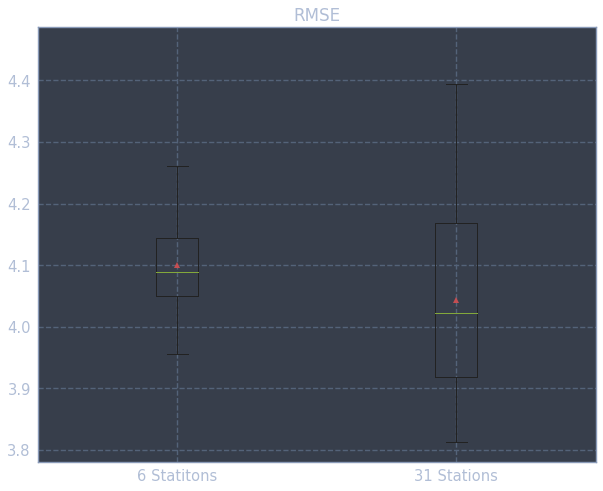

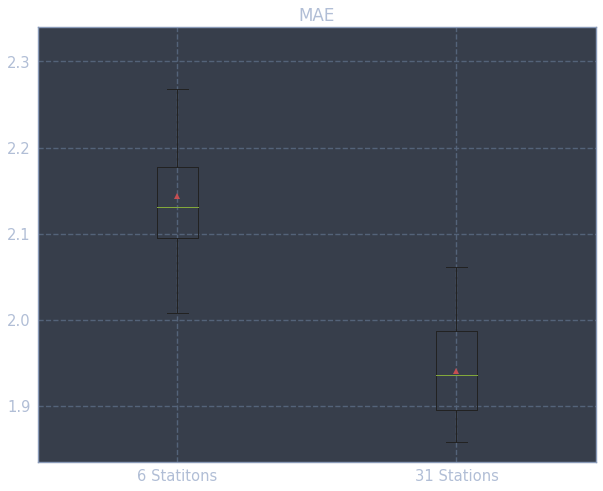

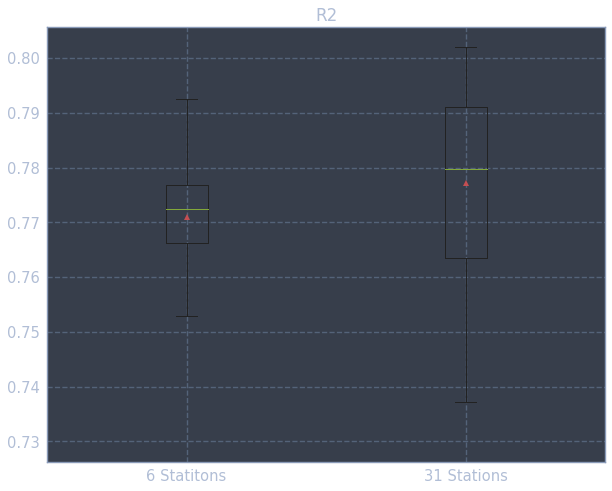

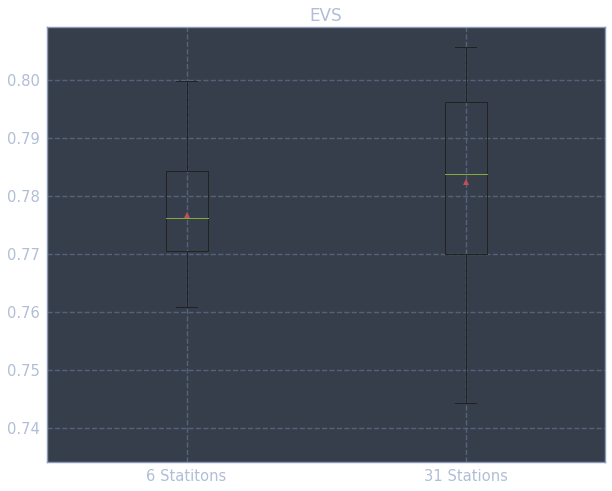

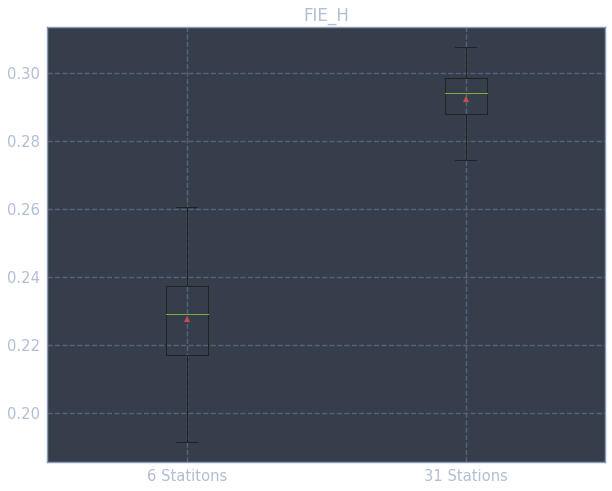

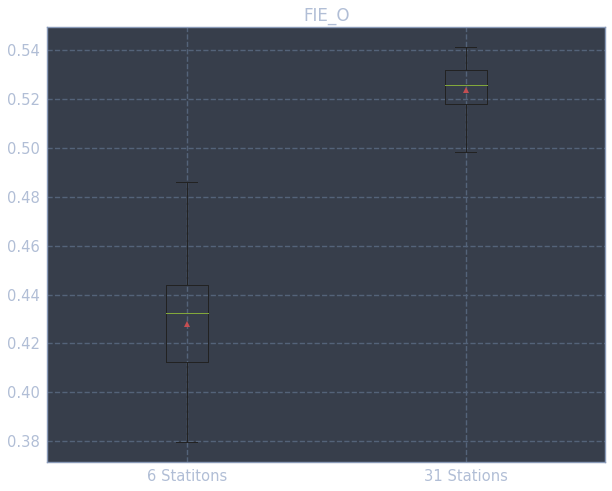

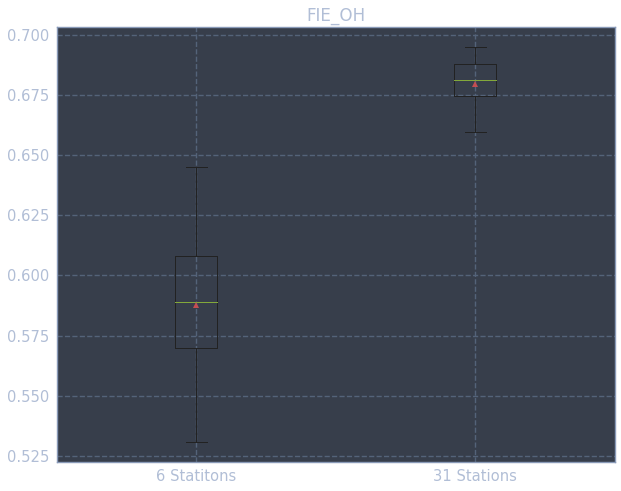

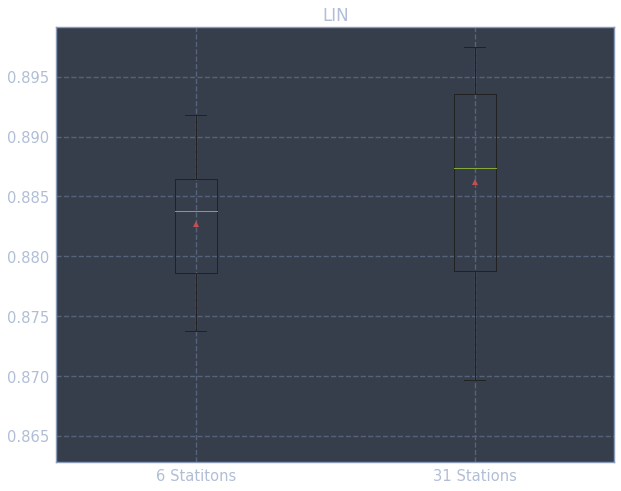

In [10]:
# I want a boxplot for each measure, showing test set comparison for 6station and 31station trained NNs
# plt.boxplot(x) makes a box for each column in x, so I need to feed 50x2 arrays to it

n = 0
for m in mess:
    plt.figure(n)
    exec(f'plt.boxplot({m}, labels=["6 Statitons", "31 Stations"], showmeans=True)')
    plt.title(m.upper())
    n += 1